In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

In [3]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [4]:
df.count()

age                         1200
gender                      1200
daily_social_media_hours    1200
platform_usage              1200
sleep_hours                 1200
screen_time_before_sleep    1200
academic_performance        1200
physical_activity           1200
social_interaction_level    1200
stress_level                1200
anxiety_level               1200
addiction_level             1200
depression_label            1200
dtype: int64

In [5]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='str')

In [6]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [7]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.nunique()

age                           7
gender                        2
daily_social_media_hours     71
platform_usage                3
sleep_hours                  51
screen_time_before_sleep     26
academic_performance        201
physical_activity            21
social_interaction_level      3
stress_level                 10
anxiety_level                10
addiction_level              10
depression_label              2
dtype: int64

In [10]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].value_counts())


gender
gender
male      615
female    585
Name: count, dtype: int64

platform_usage
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

social_interaction_level
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64


C:\Users\KIIT\AppData\Local\Temp\ipykernel_22468\3184382529.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [11]:
df['daily_social_media_hours'].describe()

count    1200.000000
mean        4.536667
std         2.029599
min         1.000000
25%         2.800000
50%         4.500000
75%         6.300000
max         8.000000
Name: daily_social_media_hours, dtype: float64

In [12]:
df.isnull().sum()

df.duplicated().sum()

df.nunique()

age                           7
gender                        2
daily_social_media_hours     71
platform_usage                3
sleep_hours                  51
screen_time_before_sleep     26
academic_performance        201
physical_activity            21
social_interaction_level      3
stress_level                 10
anxiety_level                10
addiction_level              10
depression_label              2
dtype: int64

## Which teens are spending excessive time on social media?

In [13]:
df['usage_category'] = np.where(
    df['daily_social_media_hours'] < 2,
    'Low Usage',
    np.where(
        df['daily_social_media_hours'] < 5,
        'Moderate Usage',
        'Heavy Usage'
    )
)

In [14]:
df[['daily_social_media_hours','usage_category']].head()

,daily_social_media_hours,usage_category
0,7.9,Heavy Usage
1,1.9,Low Usage
2,1.3,Low Usage
3,7.4,Heavy Usage
4,4.7,Moderate Usage


## Creating a column called Mental Health Score which calculated by adding stress level, anxiety level and addiction level

In [15]:
df['mental_health_score'] =(df['stress_level'] + df['anxiety_level'] + df['addiction_level'])

In [16]:
df["mental_health_score"].describe()

count    1200.000000
mean       16.647500
std         5.038128
min         3.000000
25%        13.000000
50%        17.000000
75%        20.000000
max        30.000000
Name: mental_health_score, dtype: float64

In [17]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label',
       'usage_category', 'mental_health_score'],
      dtype='str')

In [18]:
for col in [
    'gender',
    'platform_usage',
    'social_interaction_level',
    'depression_label'
]:
    print("\n")
    print(col)
    print(df[col].value_counts())



gender
gender
male      615
female    585
Name: count, dtype: int64


platform_usage
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64


social_interaction_level
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64


depression_label
depression_label
0    1169
1      31
Name: count, dtype: int64


# QUESTION 1:
## Do depressed teens spend more time on social media?

In [19]:
df.groupby('depression_label')['daily_social_media_hours'].mean()

depression_label
0    4.478785
1    6.719355
Name: daily_social_media_hours, dtype: float64

# QUESTION 2:
## Do depressed teens sleep less?

In [20]:
df.groupby('depression_label')['sleep_hours'].mean()

depression_label
0    6.494183
1    4.761290
Name: sleep_hours, dtype: float64

# QUESTION 3:
## Do depressed teens have higher stress?

In [21]:
df.groupby('depression_label')['stress_level'].mean()

depression_label
0    5.365269
1    8.483871
Name: stress_level, dtype: float64

# QUESTION 4:
## Do depressed teens have higher addiction?

In [22]:
df.groupby('depression_label')['addiction_level'].mean()

depression_label
0    5.571429
1    5.322581
Name: addiction_level, dtype: float64

In [23]:
df.groupby('platform_usage').agg({
    'daily_social_media_hours':'mean',
    'stress_level':'mean',
    'anxiety_level':'mean',
    'addiction_level':'mean'
})

,daily_social_media_hours,stress_level,anxiety_level,addiction_level
platform_usage,,,,
Both,4.518414,5.549872,5.488491,5.496164
Instagram,4.559367,5.498783,5.669100,5.581509
TikTok,4.531156,5.288945,5.748744,5.615578


In [24]:
corr = df.select_dtypes(include='number').corr()

corr

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,mental_health_score
age,1.000000,-0.006635,0.001530,0.075612,-0.013973,0.011086,-0.031208,0.026363,0.038265,0.010973,0.018478
daily_social_media_hours,-0.006635,1.000000,-0.009472,0.035777,0.013179,0.025546,0.030698,0.027835,-0.024964,0.175201,0.019462
sleep_hours,0.001530,-0.009472,1.000000,0.010235,0.021866,0.012701,-0.010979,-0.011879,-0.054838,-0.190630,-0.043879
screen_time_before_sleep,0.075612,0.035777,0.010235,1.000000,-0.034715,-0.026450,-0.008650,-0.010344,0.028884,-0.016502,0.005373
academic_performance,-0.013973,0.013179,0.021866,-0.034715,1.000000,0.023312,-0.000600,-0.064379,0.029354,0.001441,-0.020392
physical_activity,0.011086,0.025546,0.012701,-0.026450,0.023312,1.000000,0.012159,-0.022233,0.026200,-0.017598,0.009109
stress_level,-0.031208,0.030698,-0.010979,-0.008650,-0.000600,0.012159,1.000000,0.015811,-0.000129,0.170474,0.585165
anxiety_level,0.026363,0.027835,-0.011879,-0.010344,-0.064379,-0.022233,0.015811,1.000000,0.031154,0.169566,0.594177
addiction_level,0.038265,-0.024964,-0.054838,0.028884,0.029354,0.026200,-0.000129,0.031154,1.000000,-0.013952,0.579448
depression_label,0.010973,0.175201,-0.190630,-0.016502,0.001441,-0.017598,0.170474,0.169566,-0.013952,1.000000,0.186638


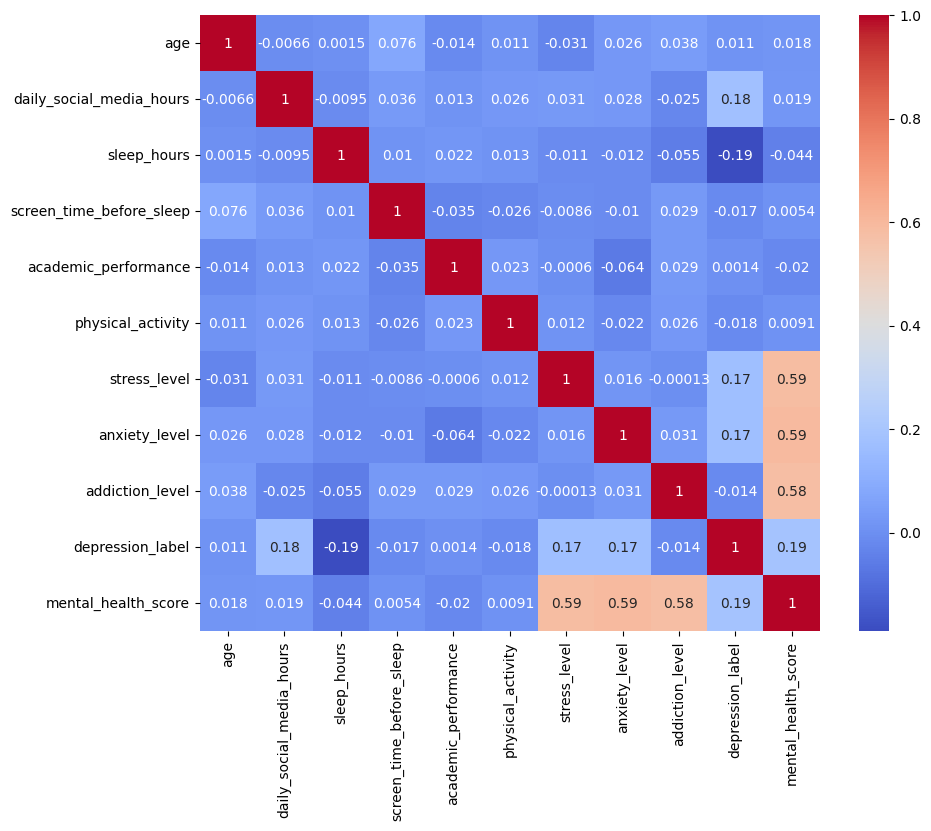

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [26]:
corr = df.select_dtypes(include='number').corr()

corr['depression_label'].sort_values(ascending=False)

depression_label            1.000000
mental_health_score         0.186638
daily_social_media_hours    0.175201
stress_level                0.170474
anxiety_level               0.169566
age                         0.010973
academic_performance        0.001441
addiction_level            -0.013952
screen_time_before_sleep   -0.016502
physical_activity          -0.017598
sleep_hours                -0.190630
Name: depression_label, dtype: float64

## Another column we are going to create is "Wellness Score"

In [27]:
df['wellness_score'] = (
    df['sleep_hours']
    + df['physical_activity']
    - df['daily_social_media_hours']
)

In [28]:
corr['depression_label'].sort_values(ascending=False)

depression_label            1.000000
mental_health_score         0.186638
daily_social_media_hours    0.175201
stress_level                0.170474
anxiety_level               0.169566
age                         0.010973
academic_performance        0.001441
addiction_level            -0.013952
screen_time_before_sleep   -0.016502
physical_activity          -0.017598
sleep_hours                -0.190630
Name: depression_label, dtype: float64

In [29]:
df.groupby('depression_label').agg({
    'daily_social_media_hours':'mean',
    'sleep_hours':'mean',
    'stress_level':'mean',
    'anxiety_level':'mean',
    'addiction_level':'mean',
    'mental_health_score':'mean'
})

,daily_social_media_hours,sleep_hours,stress_level,anxiety_level,addiction_level,mental_health_score
depression_label,,,,,,
0,4.478785,6.494183,5.365269,5.557742,5.571429,16.494440
1,6.719355,4.761290,8.483871,8.612903,5.322581,22.419355


In [30]:
df['risk_category'] = pd.cut(
    df['mental_health_score'],
    bins=[0,10,20,30],
    labels=['Low','Medium','High']
)

df[['mental_health_score','risk_category']].head()

,mental_health_score,risk_category
0,5,Low
1,19,Medium
2,8,Low
3,17,Medium
4,10,Low


In [31]:
pd.crosstab(
    df['risk_category'],
    df['depression_label']
)

depression_label,0,1
risk_category,,
Low,154,0
Medium,755,7
High,260,24


In [32]:
df.groupby('depression_label')['mental_health_score'].describe()

,count,mean,std,min,25%,50%,75%,max
depression_label,,,,,,,,
0,1169.0,16.494440,4.994707,3.0,13.0,17.0,20.0,30.0
1,31.0,22.419355,2.802073,16.0,21.0,22.0,24.0,28.0


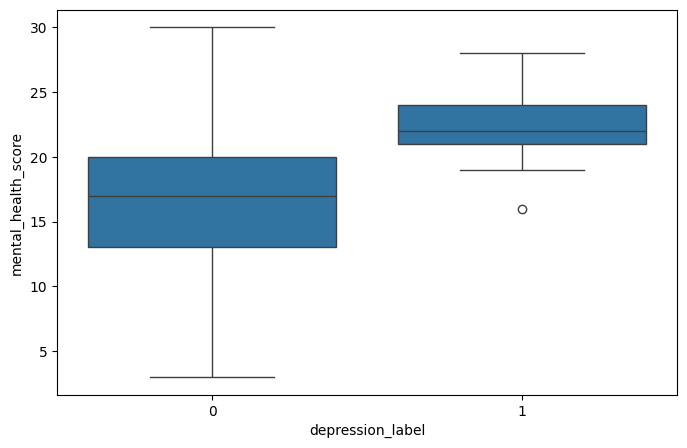

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x='depression_label',
    y='mental_health_score',
    data=df
)

plt.show()

## We create three more columns i.e Sleep Deficit, Wellness Score and Social Media Intensity

In [34]:
df['sleep_deficit'] = 8 - df['sleep_hours']

df['wellness_score'] = (
    df['sleep_hours']
    + df['physical_activity']
    - df['daily_social_media_hours']
)

df['social_media_intensity'] = (
    df['daily_social_media_hours']
    / df['sleep_hours']
)

In [35]:
df[['sleep_deficit','wellness_score','social_media_intensity']].describe()

,sleep_deficit,wellness_score,social_media_intensity
count,1200.000000,1200.000000,1200.000000
mean,1.550583,2.927250,0.742257
std,1.442677,2.560461,0.382492
min,-1.000000,-3.600000,0.117647
25%,0.400000,1.100000,0.426782
50%,1.500000,2.900000,0.720930
75%,2.800000,4.700000,0.976025
max,4.000000,9.700000,1.926829


# Dashboard Page 1: Executive Summary
### KPI Cards

In [36]:
df['daily_social_media_hours'].mean()

np.float64(4.536666666666667)

In [37]:
df['sleep_hours'].mean()

np.float64(6.449416666666667)

In [38]:
df['depression_label'].mean() *100

np.float64(2.5833333333333335)

In [39]:
df['mental_health_score'].mean()

np.float64(16.6475)

In [40]:
df['wellness_score'].mean()

np.float64(2.92725)

# Dashboard Page 2: Behavioral Analysis

### Does more social media mean less sleep?

In [41]:
df[['daily_social_media_hours',
    'sleep_hours']].corr()

,daily_social_media_hours,sleep_hours
daily_social_media_hours,1.000000,-0.009472
sleep_hours,-0.009472,1.000000


### Does more social media mean more stress?

In [42]:
df[['daily_social_media_hours',
    'stress_level']].corr()

,daily_social_media_hours,stress_level
daily_social_media_hours,1.000000,0.030698
stress_level,0.030698,1.000000


### Does more social media mean more anxiety?

In [43]:
df[['daily_social_media_hours',
    'anxiety_level']].corr()

,daily_social_media_hours,anxiety_level
daily_social_media_hours,1.000000,0.027835
anxiety_level,0.027835,1.000000


In [44]:
df.groupby('gender').agg({
    'daily_social_media_hours':'mean',
    'sleep_hours':'mean',
    'stress_level':'mean',
    'anxiety_level':'mean',
    'mental_health_score':'mean'
})

,daily_social_media_hours,sleep_hours,stress_level,anxiety_level,mental_health_score
gender,,,,,
female,4.512991,6.496410,5.422222,5.687179,16.594872
male,4.559187,6.404715,5.468293,5.588618,16.697561


In [45]:
df.groupby('social_interaction_level').agg({
    'daily_social_media_hours':'mean',
    'sleep_hours':'mean',
    'stress_level':'mean',
    'anxiety_level':'mean',
    'mental_health_score':'mean'
})

,daily_social_media_hours,sleep_hours,stress_level,anxiety_level,mental_health_score
social_interaction_level,,,,,
high,4.457182,6.483740,5.512195,5.704607,16.804878
low,4.539518,6.461687,5.349398,5.525301,16.342169
medium,4.604327,6.406731,5.483173,5.687500,16.812500


In [46]:
pd.qcut(
    df['daily_social_media_hours'],
    q=4
).value_counts()

daily_social_media_hours
(0.999, 2.8]    314
(6.3, 8.0]      298
(4.5, 6.3]      295
(2.8, 4.5]      293
Name: count, dtype: int64

In [47]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label',
       'usage_category', 'mental_health_score', 'wellness_score',
       'risk_category', 'sleep_deficit', 'social_media_intensity'],
      dtype='str')

In [48]:
df.to_csv(
    "teen_mental_health_enriched.csv",
    index=False
)